# Phase 3 — Préparation du dataset analytique

Objectifs de cette phase :
1. Documenter le schéma des colonnes (keep / drop / transform)
2. Appliquer le nettoyage (doublons)
3. Construire le **split temporel** train / test anti-fuite
4. Construire le **pipeline de prétraitement** (fit sur train uniquement)
5. Vérifier la qualité du split
6. Sauvegarder les datasets prêts à l'emploi

> **Règle absolue** : tout `fit()` (scaler, encodeur, resampler) se fait  
> **exclusivement sur le train**. Le test ne touche qu'à `transform()`.

## 0. Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, RobustScaler

from src.config import (
    RAW_DATA_PATH, DATA_DIR, RANDOM_SEED,
    TEST_TIME_THRESHOLD, N_FRAUDS, SCALE_POS_WEIGHT
)

np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
REPORTS_DIR = Path('../reports')
DATA_DIR    = Path('../data')
REPORTS_DIR.mkdir(exist_ok=True)

print('Imports OK')

Imports OK


## 1. Schéma des colonnes

Avant tout traitement, on documente la décision pour chaque colonne.

In [2]:
schema = pd.DataFrame([
    ('Time',   'float64', 'TRANSFORMER', 'Reconstruire hour=(Time//3600)%24, puis drop Time brut'),
    ('V1–V28', 'float64', 'GARDER',      'Composantes PCA déjà centrées-réduites, passthrough'),
    ('Amount', 'float64', 'TRANSFORMER', 'log1p(Amount) + RobustScaler (distribution asymétrique)'),
    ('Class',  'int64',   'CIBLE',       'Variable cible y — exclue des features'),
], columns=['Colonne', 'Type', 'Action', 'Justification'])

print(schema.to_string(index=False))

# Export markdown
with open('../reports/schema.md', 'w', encoding='utf-8') as f:
    f.write('# Schéma du dataset analytique\n\n')
    f.write('Généré automatiquement par `03_data_preparation.ipynb`\n\n')
    f.write(schema.to_markdown(index=False))
    f.write('\n\n## Règles anti-fuite\n')
    f.write('- Aucun `fit()` sur le test set\n')
    f.write('- Doublons supprimés AVANT le split\n')
    f.write('- Resampling (SMOTE) uniquement sur le train (Phase 5)\n')
print('\nschema.md exporté dans reports/')

Colonne    Type      Action                                           Justification
   Time float64 TRANSFORMER  Reconstruire hour=(Time//3600)%24, puis drop Time brut
 V1–V28 float64      GARDER     Composantes PCA déjà centrées-réduites, passthrough
 Amount float64 TRANSFORMER log1p(Amount) + RobustScaler (distribution asymétrique)
  Class   int64       CIBLE                  Variable cible y — exclue des features

schema.md exporté dans reports/


## 2. Chargement & nettoyage

On supprime les doublons (décision Phase 1) avant tout split.

In [3]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print(f'Brut         : {len(df_raw):>8,} lignes | {df_raw["Class"].sum()} fraudes')

df = df_raw.drop_duplicates().reset_index(drop=True)
print(f'Sans doublons: {len(df):>8,} lignes | {df["Class"].sum()} fraudes')
print(f'Doublons supprimés : {len(df_raw) - len(df)}')

Brut         :  284,807 lignes | 492 fraudes
Sans doublons:  283,726 lignes | 473 fraudes
Doublons supprimés : 1081


## 3. Split temporel train / test

### Pourquoi temporel et non aléatoire ?

Le dataset couvre **~48 heures** de transactions dans l'ordre chronologique.  
Un split aléatoire permettrait d'utiliser des transactions **futures** pour prédire le **passé**,  
ce qui est impossible en production. Le split temporel simule fidèlement le déploiement réel.

**Règle** : `train` = transactions avec `Time ≤ seuil` · `test` = transactions avec `Time > seuil`  
**Seuil** : 80 % de `Time` max (`TEST_TIME_THRESHOLD = 0.8`)

In [4]:
time_max   = df['Time'].max()
time_split = time_max * TEST_TIME_THRESHOLD

train = df[df['Time'] <= time_split].copy()
test  = df[df['Time'] >  time_split].copy()

print(f'Time max     : {time_max:,.0f} s  ({time_max/3600:.1f} h)')
print(f'Seuil split  : {time_split:,.0f} s  ({time_split/3600:.1f} h)')
print()
print(f'{"":<8} {"Lignes":>8} {"Fraudes":>8} {"% fraudes":>10} {"% dataset":>10}')
print('-' * 50)
for name, d in [("Train", train), ("Test", test)]:
    n_fraud = d['Class'].sum()
    print(f'{name:<8} {len(d):>8,} {n_fraud:>8} '
          f'{n_fraud/len(d)*100:>9.3f}% {len(d)/len(df)*100:>9.1f}%')
print('-' * 50)
print(f'{"Total":<8} {len(df):>8,} {df["Class"].sum():>8}')

Time max     : 172,792 s  (48.0 h)
Seuil split  : 138,234 s  (38.4 h)

           Lignes  Fraudes  % fraudes  % dataset
--------------------------------------------------
Train     210,292      376     0.179%      74.1%
Test       73,434       97     0.132%      25.9%
--------------------------------------------------
Total     283,726      473


## 4. Vérification du split

On visualise la distribution temporelle et la répartition des fraudes dans chaque set.

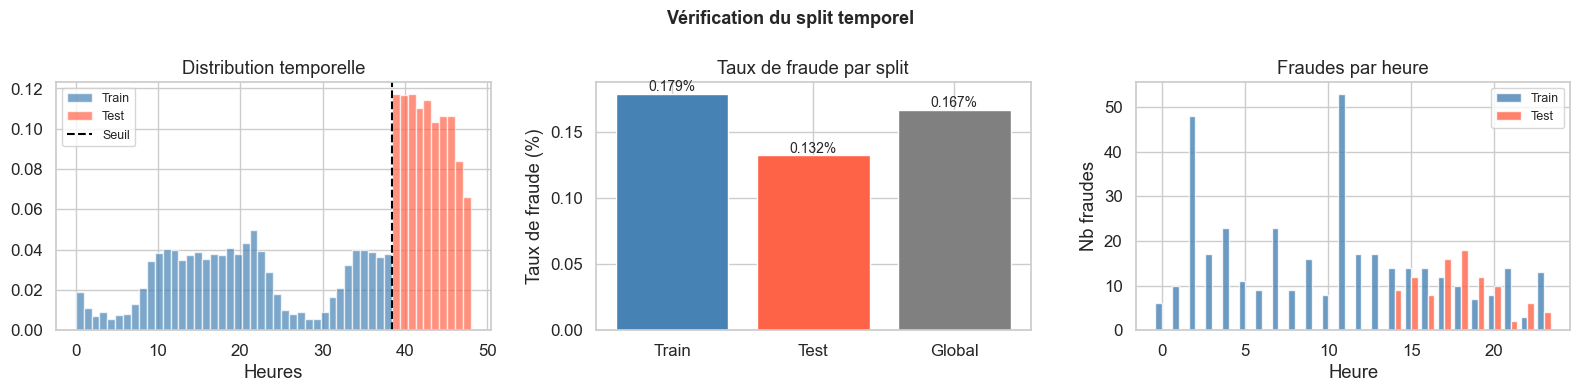

Overlap train/test : 0 transactions en commun (doit être 0)


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution temporelle
axes[0].hist(train['Time']/3600, bins=40, alpha=0.7, color='steelblue', label='Train', density=True)
axes[0].hist(test['Time']/3600,  bins=10, alpha=0.7, color='tomato',    label='Test',  density=True)
axes[0].axvline(time_split/3600, color='black', linestyle='--', linewidth=1.5, label='Seuil')
axes[0].set_xlabel('Heures')
axes[0].set_title('Distribution temporelle')
axes[0].legend(fontsize=9)

# Taux de fraude train vs test
rates = {
    'Train': train['Class'].mean() * 100,
    'Test' : test['Class'].mean()  * 100,
    'Global': df['Class'].mean()   * 100,
}
axes[1].bar(rates.keys(), rates.values(),
            color=['steelblue','tomato','gray'], edgecolor='white')
for i, (k, v) in enumerate(rates.items()):
    axes[1].text(i, v + 0.002, f'{v:.3f}%', ha='center', fontsize=10)
axes[1].set_ylabel('Taux de fraude (%)')
axes[1].set_title('Taux de fraude par split')

# Fraudes par heure dans train vs test
train_h = train.copy(); train_h['hour'] = (train_h['Time']//3600) % 24
test_h  = test.copy();  test_h['hour']  = (test_h['Time']//3600)  % 24
fr_train = train_h.groupby('hour')['Class'].sum()
fr_test  = test_h.groupby('hour')['Class'].sum()
axes[2].bar(fr_train.index - 0.2, fr_train.values, 0.4,
            color='steelblue', label='Train', alpha=0.8)
axes[2].bar(fr_test.index  + 0.2, fr_test.values,  0.4,
            color='tomato',    label='Test',  alpha=0.8)
axes[2].set_xlabel('Heure')
axes[2].set_ylabel('Nb fraudes')
axes[2].set_title('Fraudes par heure')
axes[2].legend(fontsize=9)

plt.suptitle('Vérification du split temporel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'fig10_split_verification.png', dpi=150, bbox_inches='tight')
plt.show()

# Vérification anti-fuite : aucune transaction du test dans le train
overlap = pd.merge(train[['Time','Amount']], test[['Time','Amount']],
                   on=['Time','Amount'])
print(f'Overlap train/test : {len(overlap)} transactions en commun (doit être 0)')

## 5. Feature engineering & pipeline de prétraitement

On construit ici les features décidées en Phase 1, et on les encapsule dans  
un `ColumnTransformer` scikit-learn **fitté uniquement sur le train**.

| Feature | Transformation | Justification |
|---|---|---|
| `Amount` | `log1p` + `RobustScaler` | Distribution très asymétrique |
| `hour` | Extrait de `Time`, passthrough | Pattern journalier (pic à 2h) |
| `V1`–`V28` | Passthrough | Déjà normalisées par PCA |

In [6]:
# Colonnes
V_COLS     = [f'V{i}' for i in range(1, 29)]
FEAT_COLS  = V_COLS + ['Amount', 'hour']
TARGET_COL = 'Class'

def add_hour(X):
    """Ajoute la feature hour à partir de Time."""
    X = X.copy()
    X['hour'] = (X['Time'] // 3600) % 24
    return X

# Appliquer sur train et test
train = add_hour(train)
test  = add_hour(test)

# Pipeline de prétraitement
log1p_scaler = Pipeline([
    ('log1p',  FunctionTransformer(np.log1p, validate=False)),
    ('scaler', RobustScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('v_cols',  'passthrough',  V_COLS),
        ('amount',  log1p_scaler,   ['Amount']),
        ('hour',    RobustScaler(), ['hour']),
    ],
    remainder='drop'   # drop Time, Class
)

# Fit UNIQUEMENT sur le train
X_train = train[FEAT_COLS]
y_train = train[TARGET_COL]
X_test  = test[FEAT_COLS]
y_test  = test[TARGET_COL]

preprocessor.fit(X_train)
print('Pipeline fitté sur le train uniquement — OK')

X_train_t = preprocessor.transform(X_train)
X_test_t  = preprocessor.transform(X_test)

print(f'X_train transformé : {X_train_t.shape}')
print(f'X_test  transformé : {X_test_t.shape}')
print(f'y_train — fraudes  : {y_train.sum()} / {len(y_train):,}')
print(f'y_test  — fraudes  : {y_test.sum()}  / {len(y_test):,}')

Pipeline fitté sur le train uniquement — OK
X_train transformé : (210292, 30)
X_test  transformé : (73434, 30)
y_train — fraudes  : 376 / 210,292
y_test  — fraudes  : 97  / 73,434


## 6. Vérification anti-fuite du pipeline

On confirme que le scaler est bien fitté sur le train et seulement transformé sur le test.

In [7]:
# Le scaler Amount doit avoir des paramètres issus du train uniquement
amount_scaler = preprocessor.named_transformers_['amount']['scaler']
print('Paramètres RobustScaler Amount (issus du TRAIN uniquement) :')
print(f'  center_ (médiane train) : {amount_scaler.center_[0]:.4f}')
print(f'  scale_  (IQR train)     : {amount_scaler.scale_[0]:.4f}')

# Comparer avec les vraies stats du train
log_amounts_train = np.log1p(X_train['Amount'])
print(f'  Médiane log1p(Amount) train réelle : {log_amounts_train.median():.4f}')
print(f'  IQR    log1p(Amount) train réel    : {log_amounts_train.quantile(0.75) - log_amounts_train.quantile(0.25):.4f}')
print()
print('Anti-fuite : les 2 valeurs doivent correspondre.')

Paramètres RobustScaler Amount (issus du TRAIN uniquement) :
  center_ (médiane train) : 3.1837
  scale_  (IQR train)     : 2.4484
  Médiane log1p(Amount) train réelle : 3.1837
  IQR    log1p(Amount) train réel    : 2.4484

Anti-fuite : les 2 valeurs doivent correspondre.


## 7. Sauvegarde des splits

On sauvegarde les datasets nettoyés (avec `hour`, sans doublons)  
ainsi que les arrays numpy transformés, prêts pour l'entraînement.

In [8]:
import joblib

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

# 1. DataFrames nettoyés (avec hour, avant transformation)
train.to_parquet(DATA_DIR / 'train.parquet', index=False)
test.to_parquet(DATA_DIR  / 'test.parquet',  index=False)
print('Splits sauvegardés : data/train.parquet  data/test.parquet')

# 2. Pipeline preprocessor fitté
joblib.dump(preprocessor, MODELS_DIR / 'preprocessor.joblib')
print('Preprocessor sauvegardé : models/preprocessor.joblib')

# 3. Résumé final
print()
print('=== Résumé des splits ===')
print(f'Train : {len(train):>8,} lignes | {y_train.sum():>4} fraudes ({y_train.mean()*100:.3f} %)')
print(f'Test  : {len(test):>8,} lignes | {y_test.sum():>4} fraudes ({y_test.mean()*100:.3f} %)')
print(f'Features : {X_train_t.shape[1]} ({len(V_COLS)} V* + Amount + hour)')

Splits sauvegardés : data/train.parquet  data/test.parquet
Preprocessor sauvegardé : models/preprocessor.joblib

=== Résumé des splits ===
Train :  210,292 lignes |  376 fraudes (0.179 %)
Test  :   73,434 lignes |   97 fraudes (0.132 %)
Features : 30 (28 V* + Amount + hour)


## 8. Conclusions & décisions

### Chiffres issus de l'exécution

| Indicateur | Valeur |
|---|---|
| Lignes brutes | **284 807** |
| Doublons supprimés | **1 081** (dont 19 fraudes) |
| Lignes après nettoyage | **283 726** |
| `Time` max | **172 792 s (48,0 h)** |
| Seuil du split | **138 234 s (38,4 h)** — 80 % de Time max |

### Résumé du split

| Split | Lignes | Fraudes | % fraudes | % dataset |
|---|---|---|---|---|
| **Train** | **210 292** | **376** | **0,179 %** | **74,1 %** |
| **Test** | **73 434** | **97** | **0,132 %** | **25,9 %** |
| Total | 283 726 | 473 | 0,167 % | 100 % |

> **Observation** : le taux de fraude est légèrement plus élevé dans le train (0,179 %) que dans le test (0,132 %).  
> C'est **attendu et acceptable** avec un split temporel : les patterns peuvent évoluer entre les deux jours.  
> C'est précisément ce que le split temporel est censé révéler — un split aléatoire aurait artificiellement égalisé les taux.

### Vérifications anti-fuite

| Vérification | Résultat |
|---|---|
| Overlap train / test | **0 transaction en commun** |
| `center_` RobustScaler = médiane log1p(Amount) train | **3,1837 = 3,1837** |
| `scale_` RobustScaler = IQR log1p(Amount) train | **2,4484 = 2,4484** |

### Pipeline final

| Feature | Transformation | Shape sortie |
|---|---|---|
| `V1`–`V28` | Passthrough | 28 colonnes |
| `Amount` | `log1p` + `RobustScaler` | 1 colonne |
| `hour` | `RobustScaler` | 1 colonne |
| **Total** | | **30 features** |

### Fichiers produits
- `data/train.parquet` — 210 292 lignes, 376 fraudes
- `data/test.parquet` — 73 434 lignes, 97 fraudes
- `models/preprocessor.joblib` — pipeline fitté sur le train
- `reports/schema.md` — schéma documenté
- `reports/fig10_split_verification.png` — visualisation du split

### Paramètres à reporter dans les phases suivantes
- **Phase 5** : SMOTE sur les **376 fraudes du train uniquement**
- **Phase 7** : `scale_pos_weight = 209 916 / 376 ≈ 558`
- **Phase 9** : évaluation finale sur les **97 fraudes du test**